In [1]:
# 1.) Importing the necessary files.
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# 2.) Loading the dataset.
df = pd.read_csv('/content/Tweets.csv')

In [2]:
# 3.) Will be working only on 500 rows so keeping only the first 500 rows and removing others.
df_sample = df.head(500).copy()

In [3]:
# 4.) Creating a function to calculate sentiment using TextBlob.
def get_sentiment_score(text):
    # We use str(text) to make sure empty rows don't crash the code
    analysis = TextBlob(str(text))
    # Polarity > 0 is Positive, < 0 is Negative, 0 is Neutral
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity < 0:
        return 'negative'
    else:
        return 'neutral'

In [4]:
# 5.) Applying the function to the 'text' column.
df_sample['predicted_sentiment'] = df_sample['text'].apply(get_sentiment_score)

# 6.) Checking how well it performed.
print(df_sample[['text', 'sentiment', 'predicted_sentiment']].head())

                                                text sentiment  \
0                I`d have responded, if I were going   neutral   
1      Sooo SAD I will miss you here in San Diego!!!  negative   
2                          my boss is bullying me...  negative   
3                     what interview! leave me alone  negative   
4   Sons of ****, why couldn`t they put them on t...  negative   

  predicted_sentiment  
0             neutral  
1            negative  
2             neutral  
3             neutral  
4             neutral  


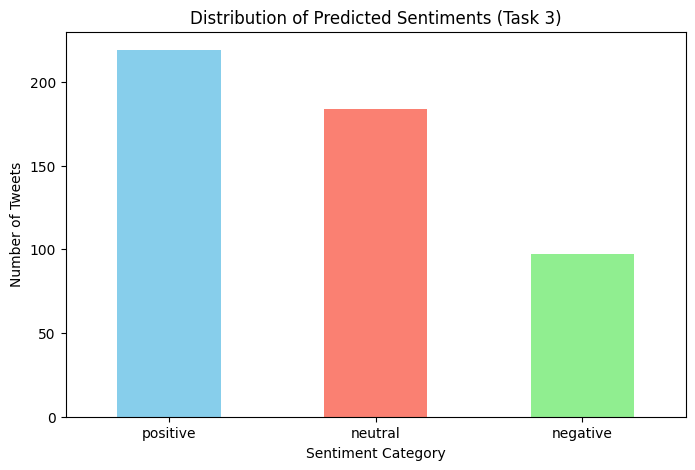

In [5]:
# 7.) Creating a bar chart.
plt.figure(figsize=(8, 5))
df_sample['predicted_sentiment'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Distribution of Predicted Sentiments (Task 3)')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.show()